# State of the art evaluation

## 1. Import Libraries and Configure Paths

In [48]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from metrics import (
    mean_average_precision_score,
    F1_score_from_sim,
    IoU_from_sim,
    F1_score_q
)

%load_ext autoreload
%autoreload 2
base_path="../zero_shot"

# CLIP4Clip
clip_path = Path(base_path) / "CLIP4Clip"
CLIP_SIM_TEST   = Path("/media/eceo_scratch_haas001/results/prompting_mammalps-v2/CLIP4Clip/test/similarity_matrix.csv")
CLIP_SIM_TRAIN  = Path("/media/eceo_scratch_haas001/results/prompting_mammalps-v2/CLIP4Clip/train/similarity_matrix.csv")
CLIP_GT_TEST    = clip_path / "dataset/test/ground_truth.json"
CLIP_GT_TRAIN   = clip_path / "dataset/train/ground_truth.json"
# SIGLIP
siglip_path = Path(base_path) / "CLIP4Clip"
SIGLIP_SIM_TEST   = Path("/media/eceo_scratch_haas001/results/prompting_mammalps-v2/SigLIP4Clip/test/similarity_matrix.csv")
SIGLIP_SIM_TRAIN  = Path("/media/eceo_scratch_haas001/results/prompting_mammalps-v2/SigLIP4Clip/train/similarity_matrix.csv")
SIGLIP_GT_TEST    = siglip_path / "dataset/test/ground_truth.json"
SIGLIP_GT_TRAIN   = siglip_path / "dataset/train/ground_truth.json"
# GRAM
gram_path = Path(base_path) / "GRAM"
GRAM_SIM_TEST   = Path("/media/eceo_scratch_haas001/results/prompting_mammalps-v2/GRAM/test/similarity_matrix.csv")
GRAM_GT_TEST    = gram_path / "dataset/test/ground_truth.json"
GRAM_SIM_TRAIN  = Path("/media/eceo_scratch_haas001/results/prompting_mammalps-v2/GRAM/train/similarity_matrix.csv")
GRAM_GT_TRAIN   = gram_path / "dataset/train/ground_truth.json"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Similarity Matrices

In [49]:
# Load raw similarity matrices  shape: (n_videos, n_queries), index = video_id
clip_sim_test_df = pd.read_csv(CLIP_SIM_TEST, index_col="video_id")
gram_sim_test_df = pd.read_csv(GRAM_SIM_TEST, index_col="video_id")
siglip_sim_test_df = pd.read_csv(SIGLIP_SIM_TEST, index_col="video_id")
clip_sim_train_df = pd.read_csv(CLIP_SIM_TRAIN, index_col="video_id")
gram_sim_train_df = pd.read_csv(GRAM_SIM_TRAIN, index_col="video_id")
siglip_sim_train_df = pd.read_csv(SIGLIP_SIM_TRAIN, index_col="video_id")

## Load Ground Truth and Per-Query Thresholds

In [50]:
# Ground truth: {query_text: {"videos": [video_id, ...], "category": "RARE"|"COMMON"}}
with open(CLIP_GT_TEST) as f:
    clip_gt = json.load(f)
with open(SIGLIP_GT_TEST) as f:
    siglip_gt = json.load(f)
with open(GRAM_GT_TEST) as f:
    gram_gt = json.load(f)

print(f"CLIP4Clip GT queries   : {len(clip_gt)}")
print(f"SigLIP4Clip GT queries : {len(siglip_gt)}")
print(f"GRAM GT queries        : {len(gram_gt)}")

# Query categories
with open("../benchmark/query_categories.json", "r") as f:
    query_categories = json.load(f)

query2eco_cat = {q: [] for q in clip_gt.keys()}
for cat in query_categories["ECOLOGY"]:
    for q in query_categories["ECOLOGY"][cat]:
        if q in query2eco_cat:
            query2eco_cat[q].append(cat)

query2cv_cat = {q: [] for q in clip_gt.keys()}
for cat in query_categories["VISION"]:
    for q in query_categories["VISION"][cat]:
        if q in query2cv_cat:
            query2cv_cat[q].append(cat)

print(f"Ecological Category values      : {set(query_categories['ECOLOGY'].keys())}")
print(f"Vision Category values          : {set(query_categories['VISION'].keys())}")

CLIP4Clip GT queries   : 113
SigLIP4Clip GT queries : 113
GRAM GT queries        : 113
Ecological Category values      : {'RARE', 'CAMERA_REACTION', 'COMMON', 'SOCIAL', 'COURTSHIP'}
Vision Category values          : {'MULTI_INDIV', 'VIDEO_COMPARISON', 'SINGLE_ATTR', 'COMPLEX', 'MULTI_ATTR'}


## Normalize Similarity Scores Per Query

In [51]:
def normalize_per_query(sim_train_df: pd.DataFrame, sim_test_df: pd.DataFrame) -> pd.DataFrame:
    """
    """
    norm_test = sim_test_df.copy().astype(float)
    norm_train = sim_train_df.copy().astype(float)
    for col in norm_test.columns:
        lo, hi = norm_train[col].min(), norm_train[col].max()
        if hi > lo:
            norm_test[col] = (norm_test[col] - lo) / (hi - lo)
            norm_train[col] = (norm_train[col] - lo) / (hi - lo)
        else:
            norm_test[col] = 0.5
            norm_train[col] = 0.5
    return norm_train, norm_test


clip_norm_train_df, clip_norm_test_df = normalize_per_query(clip_sim_train_df, clip_sim_test_df)
gram_norm_train_df, gram_norm_test_df = normalize_per_query(gram_sim_train_df, gram_sim_test_df)
siglip_norm_train_df, siglip_norm_test_df = normalize_per_query(siglip_sim_train_df, siglip_sim_test_df)

print(f"CLIP4Clip normalised range: [{clip_norm_test_df.values.min():.4f}, {clip_norm_test_df.values.max():.4f}]")
print(f"SIGLIP normalised range   : [{siglip_norm_test_df.values.min():.4f}, {siglip_norm_test_df.values.max():.4f}]")
print(f"GRAM normalised range     : [{gram_norm_test_df.values.min():.4f}, {gram_norm_test_df.values.max():.4f}]")
print(f"CLIP4Clip normalised range train: [{clip_norm_train_df.values.min():.4f}, {clip_norm_train_df.values.max():.4f}]")
print(f"SIGLIP normalised range train   : [{siglip_norm_train_df.values.min():.4f}, {siglip_norm_train_df.values.max():.4f}]")
print(f"GRAM normalised range train     : [{gram_norm_train_df.values.min():.4f}, {gram_norm_train_df.values.max():.4f}]")

CLIP4Clip normalised range: [-0.1529, 1.0915]
SIGLIP normalised range   : [-0.1985, 1.1934]
GRAM normalised range     : [-0.0199, 1.4575]
CLIP4Clip normalised range train: [0.0000, 1.0000]
SIGLIP normalised range train   : [0.0000, 1.0000]
GRAM normalised range train     : [0.0000, 1.0000]


In [52]:
# mAP is a ranking metric  no threshold needed, computed on TEST split for both models
mAP_clip, APs_clip = mean_average_precision_score(clip_gt, clip_norm_test_df)   
mAP_gram, APs_gram = mean_average_precision_score(gram_gt, gram_norm_test_df)
mAP_siglip, APs_siglip = mean_average_precision_score(siglip_gt, siglip_norm_test_df)
print(f"CLIP4Clip mAP (test): {mAP_clip:.3f}")
print(f"GRAM      mAP (test): {mAP_gram:.3f}")
print(f"SIGLIP    mAP (test): {mAP_siglip:.3f}")

CLIP4Clip mAP (test): 0.086
GRAM      mAP (test): 0.073
SIGLIP    mAP (test): 0.076


## Find Optimal Thresholds on Train Split

In [53]:
step_cste = 0.05

### CLIP4Clip

In [54]:
with open(CLIP_GT_TRAIN, "r") as f:
    gt_queries_videos_train_clip = json.load(f)
queries = gt_queries_videos_train_clip.keys()

In [55]:
clip_norm_train_df["A juvenile roe deer preparing to suckle."]

video_id
S1_C1_E104_V0262    0.397064
S1_C1_E104_V0263    0.421272
S1_C1_E104_V0264    0.437104
S1_C1_E104_V0265    0.371251
S1_C1_E104_V0266    0.394929
                      ...   
S3_C5_F930_V0504    0.399895
S3_C5_F934_V0508    0.323271
S3_C5_F953_V0782    0.346011
S3_C6_F633_V0019    0.717981
S3_C6_F633_V0020    0.576015
Name: A juvenile roe deer preparing to suckle., Length: 2090, dtype: float64

In [56]:
len(gt_queries_videos_train_clip["A juvenile roe deer preparing to suckle."]["videos"])

0

In [57]:
thrs = np.arange(clip_norm_train_df.values.min(), clip_norm_train_df.values.max(), step=step_cste)
best_t_clip = dict.fromkeys(gt_queries_videos_train_clip.keys())
all_train_videos = list([f.stem for f in Path(
    "/media/EVO870/datasets/prompting-mammalps-v2/annotations/train"
).rglob("*.json")])
all_test_videos = list([f.stem for f in Path(
    "/media/EVO870/datasets/prompting-mammalps-v2/annotations/test"
).rglob("*.json")])
for q in gt_queries_videos_train_clip.keys():
    best_f1 = 0
    if q not in clip_norm_train_df.columns:
        print(f"Query {q} has not been processed")
        continue
    gt_videos_q = list(gt_queries_videos_train_clip[q]["videos"])
    for t in thrs:
        ass_videos_q = list(clip_norm_train_df.index[clip_norm_train_df[q] > t])
        if len(gt_videos_q) == 0:  # Empty query: measure the opposite
            gt_eff = all_train_videos
            pred_eff = list(set(all_train_videos) - set(ass_videos_q))
        else:
            gt_eff = gt_videos_q
            pred_eff = ass_videos_q
        f1 = F1_score_q(gt_eff, pred_eff)
        if not np.isnan(f1) and f1 > best_f1:
            best_f1 = f1
            best_t_clip[q] = t

    if best_t_clip[q] is None:
        print(f"No best threshold found for {q}, using min similarity score as threshold")
        best_t_clip[q] = thrs[0]

In [58]:
mF1_clip, F1_queries_clip = F1_score_from_sim(gt_queries_videos=gt_queries_videos_train_clip, sim_matrix_df=clip_norm_train_df, best_thresholds=best_t_clip, all_videos=all_train_videos)
mIoU_clip, IoU_queries_clip = IoU_from_sim(gt_queries_videos=gt_queries_videos_train_clip, sim_matrix_df=clip_norm_train_df, best_thresholds=best_t_clip, all_videos=all_train_videos)

In [59]:
print(f"F1-score (macro-avg.): {mF1_clip:.3f}")
print(f"mean IoU: {mIoU_clip:.3f}")

F1-score (macro-avg.): 0.205
mean IoU: 0.167


### GRAM

In [60]:
with open(GRAM_GT_TRAIN, "r") as f:
    gt_queries_videos_train_gram = json.load(f)
queries = gt_queries_videos_train_gram.keys()

In [61]:
thrs = np.arange(gram_norm_train_df.values.min(), gram_norm_train_df.values.max(), step=step_cste)
best_t_gram = dict.fromkeys(gt_queries_videos_train_gram.keys())

for q in gt_queries_videos_train_gram.keys():
    best_f1 = 0
    if q not in gram_norm_train_df.columns:
        print(f"Query {q} has not been processed")
        continue
    gt_videos_q = list(gt_queries_videos_train_gram[q]["videos"])
    for t in thrs:
        ass_videos_q = list(gram_norm_train_df.index[gram_norm_train_df[q] > t])
        if len(gt_videos_q) == 0:  # Empty query: measure the opposite
            gt_eff = all_train_videos
            pred_eff = list(set(all_train_videos) - set(ass_videos_q))
        else:
            gt_eff = gt_videos_q
            pred_eff = ass_videos_q
        f1 = F1_score_q(gt_eff, pred_eff)
        if not np.isnan(f1) and f1 > best_f1:
            best_f1 = f1
            best_t_gram[q] = t

    if best_t_gram[q] is None:
        print(f"No best threshold found for {q}, using min similarity score as threshold")
        best_t_gram[q] = thrs[0]

In [62]:
mF1_gram, F1_queries_gram = F1_score_from_sim(gt_queries_videos=gt_queries_videos_train_gram, sim_matrix_df=gram_norm_train_df, best_thresholds=best_t_gram, all_videos=all_train_videos)
mIoU_gram, IoU_queries_gram = IoU_from_sim(gt_queries_videos=gt_queries_videos_train_gram, sim_matrix_df=gram_norm_train_df, best_thresholds=best_t_gram, all_videos=all_train_videos)

In [63]:
print(f"F1-score (macro-avg.): {mF1_gram:.3f}")
print(f"mean IoU: {mIoU_gram:.3f}")

F1-score (macro-avg.): 0.206
mean IoU: 0.167


In [64]:
results_df = pd.concat([
    pd.DataFrame.from_dict(IoU_queries_gram, orient="index", columns=["mIoU"]),
    pd.DataFrame.from_dict(F1_queries_gram, orient="index", columns=["F1-score"]),
    ], axis=1)

eco_cat_df = pd.DataFrame([query2eco_cat], index=["eco_cat"]).T
cv_cat_df = pd.DataFrame([query2cv_cat], index=["cv_cat"]).T
results_cat_df = results_df.merge(eco_cat_df, left_index=True, right_index=True).merge(cv_cat_df, left_index=True, right_index=True)

### SIGLIP

In [65]:
with open(SIGLIP_GT_TRAIN, "r") as f:
    gt_queries_videos_train_siglip = json.load(f)

In [66]:
thrs = np.arange(siglip_norm_train_df.values.min(), siglip_norm_train_df.values.max(), step=step_cste)
best_t_siglip = dict.fromkeys(gt_queries_videos_train_siglip.keys())

for q in gt_queries_videos_train_siglip.keys():
    best_f1 = 0
    if q not in siglip_norm_train_df.columns:
        print(f"Query {q} has not been processed")
        continue
    gt_videos_q = list(gt_queries_videos_train_siglip[q]["videos"])
    for t in thrs:
        ass_videos_q = list(siglip_norm_train_df.index[siglip_norm_train_df[q] > t])
        if len(gt_videos_q) == 0:  # Empty query: measure the opposite
            gt_eff = all_train_videos
            pred_eff = list(set(all_train_videos) - set(ass_videos_q))
        else:
            gt_eff = gt_videos_q
            pred_eff = ass_videos_q
        f1 = F1_score_q(gt_eff, pred_eff)
        if not np.isnan(f1) and f1 > best_f1:
            best_f1 = f1
            best_t_siglip[q] = t

    if best_t_siglip[q] is None:
        print(f"No best threshold found for {q}, using min similarity score as threshold")
        best_t_siglip[q] = thrs[0]

In [67]:
mF1_siglip, F1_queries_siglip = F1_score_from_sim(gt_queries_videos=gt_queries_videos_train_siglip, sim_matrix_df=siglip_norm_train_df, best_thresholds=best_t_siglip, all_videos=all_train_videos)
mIoU_siglip, IoU_queries_siglip = IoU_from_sim(gt_queries_videos=gt_queries_videos_train_siglip, sim_matrix_df=siglip_norm_train_df, best_thresholds=best_t_siglip, all_videos=all_train_videos)

In [68]:
print(f"F1-score (macro-avg.): {mF1_siglip:.3f}")
print(f"mean IoU: {mIoU_siglip:.3f}")

F1-score (macro-avg.): 0.198
mean IoU: 0.162


## Evaluate on Test Split (Thresholds Calibrated on Train)

The per-query thresholds found above are now applied to the **held-out test split**.
This is the only number that should appear in the paper.

In [69]:
# Apply calibrated thresholds to the normalized TEST similarity matrices
mF1_clip_test, F1_queries_clip_test = F1_score_from_sim(
    gt_queries_videos=clip_gt,
    sim_matrix_df=clip_norm_test_df,
    best_thresholds=best_t_clip,
    all_videos=all_train_videos
)
mIoU_clip_test, IoU_queries_clip_test = IoU_from_sim(
    gt_queries_videos=clip_gt,
    sim_matrix_df=clip_norm_test_df,
    best_thresholds=best_t_clip,
    all_videos=all_train_videos
)

mF1_siglip_test, F1_queries_siglip_test = F1_score_from_sim(
    gt_queries_videos=siglip_gt,
    sim_matrix_df=siglip_norm_test_df,
    best_thresholds=best_t_siglip,
    all_videos=all_train_videos
)
mIoU_siglip_test, IoU_queries_siglip_test = IoU_from_sim(
    gt_queries_videos=siglip_gt,
    sim_matrix_df=siglip_norm_test_df,
    best_thresholds=best_t_siglip,
    all_videos=all_train_videos
)

mF1_gram_test, F1_queries_gram_test = F1_score_from_sim(
    gt_queries_videos=gram_gt,
    sim_matrix_df=gram_norm_test_df,
    best_thresholds=best_t_gram,
    all_videos=all_train_videos 
)
mIoU_gram_test, IoU_queries_gram_test = IoU_from_sim(
    gt_queries_videos=gram_gt,
    sim_matrix_df=gram_norm_test_df,
    best_thresholds=best_t_gram,
    all_videos=all_train_videos
)

print("Test performance (thresholds from train):")
print(f"  CLIP4Clip  F1={mF1_clip_test:.3f}  mIoU={mIoU_clip_test:.3f}  mAP={mAP_clip:.3f}")
print(f"  SIGLIP     F1={mF1_siglip_test:.3f}  mIoU={mIoU_siglip_test:.3f}  mAP={mAP_siglip:.3f}")
print(f"  GRAM       F1={mF1_gram_test:.3f}  mIoU={mIoU_gram_test:.3f}  mAP={mAP_gram:.3f}")

Test performance (thresholds from train):
  CLIP4Clip  F1=0.195  mIoU=0.162  mAP=0.086
  SIGLIP     F1=0.191  mIoU=0.160  mAP=0.076
  GRAM       F1=0.180  mIoU=0.152  mAP=0.073


## Summary Table

In [70]:
best_t_gram

{'An animal engaged in any activity other than foraging.': np.float64(0.1),
 'An animal that is neither a red deer nor a roe deer.': np.float64(0.05),
 'An animal running.': np.float64(0.0),
 'An animal bathing.': np.float64(0.35000000000000003),
 'A roe deer grazing.': np.float64(0.8500000000000001),
 'An animal browsing.': np.float64(0.75),
 'An adult roe deer sniffing.': np.float64(0.8500000000000001),
 'A juvenile red deer scratching its body.': np.float64(0.9),
 'A juvenile roe deer preparing to suckle.': np.float64(0.9500000000000001),
 'A chamois trotting.': np.float64(0.45),
 'An adult male roe deer jumping.': np.float64(0.2),
 'An adult male red deer rubbing its antlers on the ground.': np.float64(0.65),
 'A fox sniffing.': np.float64(0.8),
 'A fox chasing prey.': np.float64(0.9500000000000001),
 'A wolf chasing prey.': np.float64(0.75),
 'A hare.': np.float64(0.1),
 'A marten.': np.float64(0.2),
 'A juvenile red deer playing.': np.float64(0.9),
 'An adult red deer browsing.':

In [71]:
def aggregate(df: pd.DataFrame) -> dict:
    """Compute mIoU, macro F1, and mAP from per-query results."""
    return {
        "mIoU":       df["iou"].mean(),
        "F1 (macro)": df["f1"].mean(),
        "mAP":        df["ap"].mean(skipna=True),
    }

# Build per-query results DataFrames from TEST split
clip_results = pd.DataFrame({
    "query":     list(F1_queries_clip_test.keys()),
    "iou":       list(IoU_queries_clip_test.values()),
    "f1":        list(F1_queries_clip_test.values()),
    "ap":        [APs_clip.get(q, np.nan) for q in F1_queries_clip_test.keys()],
    "threshold": [best_t_clip.get(q, np.nan) for q in F1_queries_clip_test.keys()],
}).set_index("query")

siglip_results = pd.DataFrame({
    "query":     list(F1_queries_siglip_test.keys()),
    "iou":       list(IoU_queries_siglip_test.values()),
    "f1":        list(F1_queries_siglip_test.values()),
    "ap":        [APs_siglip.get(q, np.nan) for q in F1_queries_siglip_test.keys()],
    "threshold": [best_t_siglip.get(q, np.nan) for q in F1_queries_siglip_test.keys()],
}).set_index("query")

gram_results = pd.DataFrame({
    "query":     list(F1_queries_gram_test.keys()),
    "iou":       list(IoU_queries_gram_test.values()),
    "f1":        list(F1_queries_gram_test.values()),
    "ap":        [APs_gram.get(q, np.nan) for q in F1_queries_gram_test.keys()],
    "threshold": [best_t_gram.get(q, np.nan) for q in F1_queries_gram_test.keys()],
}).set_index("query")

clip_agg    = aggregate(clip_results)
siglip_agg  = aggregate(siglip_results)
gram_agg    = aggregate(gram_results)

summary_df = pd.DataFrame(
    [clip_agg, siglip_agg, gram_agg],
    index=["CLIP4Clip (zero-shot)", "SIGLIP (zero-shot)", "GRAM (zero-shot)"]
)

print("=" * 55)
print("  End-to-end TVR Performance on MammAlps Test Split")
print("=" * 55)
display(
    summary_df.style
    .format("{:.3f}")
    .set_caption("zero-shot evaluation  |  threshold calibrated on train split, evaluated on test split")
)

# LaTeX row for the paper
for model, row in summary_df.iterrows():
    print(f"{model:40s} & {row['mIoU']:.2f} & {row['F1 (macro)']:.2f} & {row['mAP']:.2f} \\\\")

  End-to-end TVR Performance on MammAlps Test Split


,mIoU,F1 (macro),mAP
CLIP4Clip (zero-shot),0.162,0.195,0.086
SIGLIP (zero-shot),0.160,0.191,0.076
GRAM (zero-shot),0.152,0.180,0.073


CLIP4Clip (zero-shot)                    & 0.16 & 0.19 & 0.09 \\
SIGLIP (zero-shot)                       & 0.16 & 0.19 & 0.08 \\
GRAM (zero-shot)                         & 0.15 & 0.18 & 0.07 \\


In [72]:
clip_results.loc["An animal engaged in any activity other than foraging.",:]

iou          0.406130
f1           0.577657
ap           0.562997
threshold    0.050000
Name: An animal engaged in any activity other than foraging., dtype: float64

In [73]:
results_df = pd.concat([
    pd.DataFrame.from_dict(IoU_queries_siglip, orient="index", columns=["mIoU"]),
    pd.DataFrame.from_dict(F1_queries_siglip, orient="index", columns=["F1-score"]),
    ], axis=1)

eco_cat_df = pd.DataFrame([query2eco_cat], index=["eco_cat"]).T
cv_cat_df = pd.DataFrame([query2cv_cat], index=["cv_cat"]).T
results_cat_df = results_df.merge(eco_cat_df, left_index=True, right_index=True).merge(cv_cat_df, left_index=True, right_index=True)

In [74]:
# Add category from the TEST ground-truth (same queries as test results)
for query, val in clip_gt.items():
    category = val["category"]
    if query in clip_results.index:
        clip_results.loc[query, "category"] = category

for query, val in siglip_gt.items():
    category = val["category"]
    if query in siglip_results.index:
        siglip_results.loc[query, "category"] = category

for query, val in gram_gt.items():
    category = val["category"]
    if query in gram_results.index:
        gram_results.loc[query, "category"] = category

In [75]:
clip_results

,iou,f1,ap,threshold,category
query,,,,,
An animal engaged in any activity other than foraging.,0.406130,0.577657,0.562997,0.05,RARE
An animal that is neither a red deer nor a roe deer.,0.025940,0.050569,0.016045,0.10,RARE
An animal running.,0.122302,0.217949,0.180409,0.50,RARE
An animal bathing.,0.000000,0.000000,0.087593,0.80,RARE
A roe deer grazing.,0.000000,0.000000,0.010787,0.80,RARE
...,...,...,...,...,...
"An animal foraging, then reacting to a camera, and then running away.",0.019608,0.038462,0.035645,0.75,CAMERA_REACTION
An animal reacting to a camera in rainy or overcast weather.,0.040816,0.078431,0.195017,0.65,CAMERA_REACTION
An animal reacting to a camera in clear or sunny weather.,0.050000,0.095238,0.075917,0.30,CAMERA_REACTION


## Breakdown by Category (RARE / COMMON)

In [76]:
rows = []
for model_name, df in [("CLIP4Clip", clip_results), ("SIGLIP", siglip_results), ("GRAM", gram_results)]:
    display(df.head(3))
    for cat, sub in df.groupby("category"):
        a = aggregate(sub)
        rows.append({"Model": model_name, "Category": cat, **a, "n_queries": len(sub)})

cat_df = pd.DataFrame(rows).set_index(["Model", "Category"])
display(cat_df.style.format({"mIoU": "{:.3f}", "F1 (macro)": "{:.3f}", "mAP": "{:.3f}", "n_queries": "{:.0f}"}))

,iou,f1,ap,threshold,category
query,,,,,
An animal engaged in any activity other than foraging.,0.406130,0.577657,0.562997,0.05,RARE
An animal that is neither a red deer nor a roe deer.,0.025940,0.050569,0.016045,0.10,RARE
An animal running.,0.122302,0.217949,0.180409,0.50,RARE


,iou,f1,ap,threshold,category
query,,,,,
An animal engaged in any activity other than foraging.,0.406369,0.577899,0.395924,0.1,RARE
An animal that is neither a red deer nor a roe deer.,0.026076,0.050826,0.015983,0.2,RARE
An animal running.,0.120000,0.214286,0.114660,0.0,RARE


,iou,f1,ap,threshold,category
query,,,,,
An animal engaged in any activity other than foraging.,0.402548,0.574024,0.366011,0.10,RARE
An animal that is neither a red deer nor a roe deer.,0.025873,0.050441,0.014691,0.05,RARE
An animal running.,0.120000,0.214286,0.177656,0.00,RARE


## Threshold Analysis Across Queries

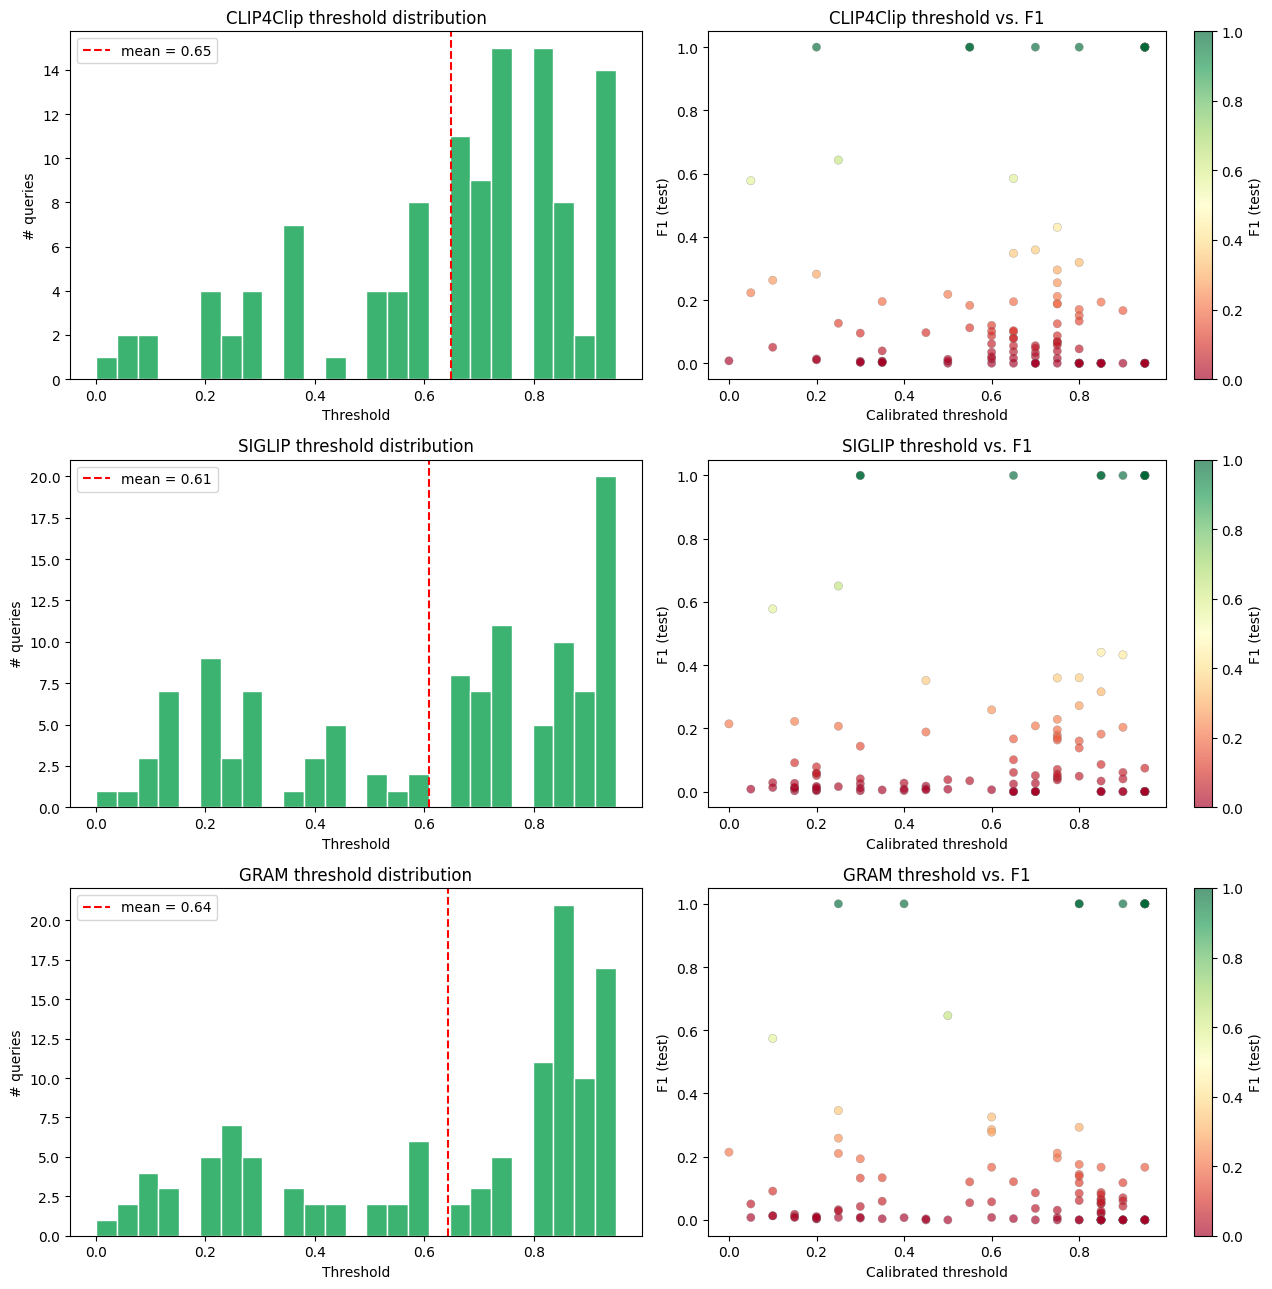

In [77]:
fig, axes = plt.subplots(3, 2, figsize=(13, 13))

for row_idx, (res_df, model_name) in enumerate([
    (clip_results, "CLIP4Clip"),
    (siglip_results, "SIGLIP"),
    (gram_results, "GRAM"),
]):
    thresholds = res_df["threshold"].values
    f1s        = res_df["f1"].values

    # Threshold distribution
    ax_hist = axes[row_idx, 0]
    ax_hist.hist(thresholds, bins=25, color="mediumseagreen", edgecolor="white")
    ax_hist.axvline(thresholds.mean(), color="red", linewidth=1.5, linestyle="--",
                    label=f"mean = {thresholds.mean():.2f}")
    ax_hist.set_title(f"{model_name} threshold distribution")
    ax_hist.set_xlabel("Threshold")
    ax_hist.set_ylabel("# queries")
    ax_hist.legend()

    # Threshold vs F1 scatter
    ax_scat = axes[row_idx, 1]
    sc = ax_scat.scatter(thresholds, f1s, c=f1s, cmap="RdYlGn", vmin=0, vmax=1,
                         alpha=0.65, edgecolors="grey", linewidths=0.3)
    plt.colorbar(sc, ax=ax_scat, label="F1 (test)")
    ax_scat.set_title(f"{model_name} threshold vs. F1")
    ax_scat.set_xlabel("Calibrated threshold")
    ax_scat.set_ylabel("F1 (test)")

plt.tight_layout()
plt.show()

## Per-Query Breakdown Table

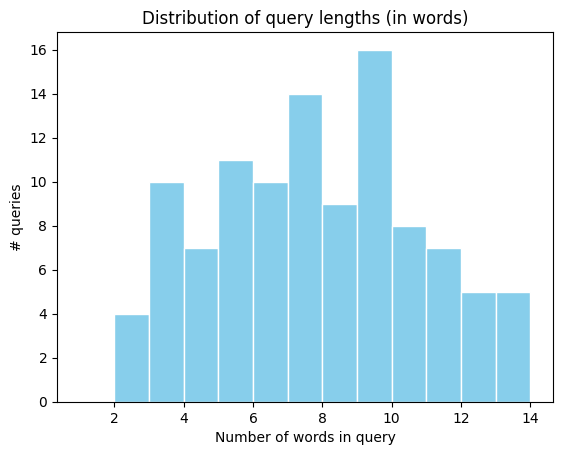

In [78]:
clip_results.index.to_list()
# histogram of count of words in queries
df_queries = pd.DataFrame({"query": clip_results.index})
df_queries["n_words"] = df_queries["query"].apply(lambda x: len(x.split()))
plt.hist(df_queries["n_words"], bins=range(1, 15), color="skyblue", edgecolor="white")
plt.title("Distribution of query lengths (in words)")
plt.xlabel("Number of words in query")
plt.ylabel("# queries")
plt.show()


In [79]:
# Merge per-query results from all three models
merged = clip_results[["category", "threshold", "f1", "iou", "ap"]].copy()
merged = merged.rename(columns={"threshold": "thr_clip", "f1": "f1_clip", "iou": "iou_clip", "ap": "ap_clip"})

siglip_cols = siglip_results[["threshold", "f1", "iou", "ap"]].rename(
    columns={"threshold": "thr_siglip", "f1": "f1_siglip", "iou": "iou_siglip", "ap": "ap_siglip"}
)
gram_cols = gram_results[["threshold", "f1", "iou", "ap"]].rename(
    columns={"threshold": "thr_gram", "f1": "f1_gram", "iou": "iou_gram", "ap": "ap_gram"}
)

merged = merged.merge(siglip_cols, left_index=True, right_index=True, how="outer")
merged = merged.merge(gram_cols,   left_index=True, right_index=True, how="outer")

merged["f1_diff_clip_gram"]   = merged["f1_clip"]   - merged["f1_gram"]
merged["f1_diff_siglip_gram"] = merged["f1_siglip"] - merged["f1_gram"]
merged = merged.sort_values("f1_diff_clip_gram", ascending=False)

merged

,category,thr_clip,f1_clip,iou_clip,ap_clip,thr_siglip,f1_siglip,iou_siglip,ap_siglip,thr_gram,f1_gram,iou_gram,ap_gram,f1_diff_clip_gram,f1_diff_siglip_gram
query,,,,,,,,,,,,,,,
An adult red deer standing with its head up while participating in courtship.,COURTSHIP,0.75,0.430108,0.273973,0.297179,0.80,0.360000,0.219512,0.350177,0.85,0.051282,0.026316,0.099639,0.378825,0.308718
An animal being vigilant while the weather is rainy or overcast.,SOCIAL,0.65,0.584615,0.413043,0.583434,0.25,0.206816,0.115334,0.099998,0.25,0.210275,0.117490,0.081163,0.374341,-0.003459
An adult red deer vocalizing while participating in courtship.,COURTSHIP,0.70,0.358491,0.218391,0.288607,0.85,0.440678,0.282609,0.446673,0.85,0.062500,0.032258,0.096569,0.295991,0.378178
A video of an animal drinking.,RARE,0.75,0.295082,0.173077,0.157009,0.95,0.074074,0.038462,0.110470,0.90,0.000000,0.000000,0.094604,0.295082,0.074074
An adult male red deer being vigilant after vocalizing.,COURTSHIP,0.80,0.318841,0.189655,0.209714,0.90,0.432432,0.275862,0.425532,0.85,0.056338,0.028986,0.045540,0.262503,0.376094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
An animal bathing.,RARE,0.80,0.000000,0.000000,0.087593,0.75,0.163265,0.088889,0.102304,0.35,0.133333,0.071429,0.063991,-0.133333,0.029932
A video of two or more red deer escaping.,SOCIAL,0.95,0.000000,0.000000,0.056021,0.95,0.000000,0.000000,0.027343,0.95,0.166667,0.090909,0.199508,-0.166667,-0.166667
A video of an individual sniffing while reacting to a camera.,CAMERA_REACTION,0.85,0.000000,0.000000,0.011754,0.15,0.013245,0.006667,0.004818,0.60,0.166667,0.090909,0.105641,-0.166667,-0.153422


In [80]:
# Add ecological category to merged (explode so multi-cat queries appear in each relevant group)
merged["eco_cat"] = merged.index.map(query2eco_cat)

eco_breakdown = (
    merged[["eco_cat", "f1_clip", "iou_clip", "f1_siglip", "iou_siglip", "f1_gram", "iou_gram"]]
    .explode("eco_cat")
    .groupby("eco_cat")
    .mean(numeric_only=True)
)

# Rename columns for readability
eco_breakdown.columns = pd.MultiIndex.from_tuples([
    ("CLIP4Clip",  "F1"),
    ("CLIP4Clip",  "mIoU"),
    ("SigLIP",     "F1"),
    ("SigLIP",     "mIoU"),
    ("GRAM",       "F1"),
    ("GRAM",       "mIoU"),
])

display(eco_breakdown.T.style.format("{:.3f}").set_caption("Per ecological category  F1 & mIoU (test split)"))

In [81]:
merged[merged["f1_clip"] < 0.1].sort_values("f1_clip", ascending=False).groupby("category").mean(numeric_only=True) # mean per category

,thr_clip,f1_clip,iou_clip,ap_clip,thr_siglip,f1_siglip,iou_siglip,ap_siglip,thr_gram,f1_gram,iou_gram,ap_gram,f1_diff_clip_gram,f1_diff_siglip_gram
category,,,,,,,,,,,,,,
CAMERA_REACTION,0.707692,0.039621,0.020457,0.068507,0.396154,0.018864,0.009597,0.011930,0.823077,0.049172,0.026100,0.044255,-0.009550,-0.030308
COMMON,0.450000,0.096774,0.050847,0.050257,0.700000,0.026316,0.013333,0.017867,0.700000,0.000000,0.000000,0.016542,0.096774,0.026316
COURTSHIP,0.716667,0.015595,0.008106,0.037815,0.733333,0.018625,0.009560,0.064372,0.675000,0.009441,0.004804,0.054933,0.006154,0.009184
RARE,0.590741,0.011569,0.005888,0.017275,0.564815,0.033199,0.017771,0.035453,0.477778,0.039483,0.022109,0.038783,-0.027914,-0.006284
SOCIAL,0.656250,0.021388,0.011048,0.025004,0.700000,0.033751,0.017888,0.035533,0.671875,0.028523,0.015163,0.045790,-0.007134,0.005228


In [82]:
merged[merged['category']=="COMMON"]

,category,thr_clip,f1_clip,iou_clip,ap_clip,thr_siglip,f1_siglip,iou_siglip,ap_siglip,thr_gram,f1_gram,iou_gram,ap_gram,f1_diff_clip_gram,f1_diff_siglip_gram,eco_cat
query,,,,,,,,,,,,,,,,
An empty video.,COMMON,0.45,0.096774,0.050847,0.050257,0.70,0.026316,0.013333,0.017867,0.7,0.000000,0.000000,0.016542,0.096774,0.026316,[COMMON]
A single adult red deer foraging only.,COMMON,0.25,0.642732,0.473548,0.387927,0.25,0.650392,0.481912,0.427187,0.5,0.646154,0.477273,0.538744,-0.003422,0.004238,[COMMON]


In [83]:
merged_short = merged[merged.index.to_series().apply(lambda x: len(x.split())) < 10].copy()
merged_short["n_words"] = merged_short.index.to_series().apply(lambda x: len(x.split()))
merged_short.groupby("category").mean(numeric_only=True)

,thr_clip,f1_clip,iou_clip,ap_clip,thr_siglip,f1_siglip,iou_siglip,ap_siglip,thr_gram,f1_gram,iou_gram,ap_gram,f1_diff_clip_gram,f1_diff_siglip_gram,n_words
category,,,,,,,,,,,,,,,
CAMERA_REACTION,0.708333,0.222598,0.196076,0.080540,0.458333,0.194072,0.180743,0.018985,0.787500,0.207125,0.187878,0.050781,0.015472,-0.013054,7.500000
COMMON,0.350000,0.369753,0.262198,0.219092,0.475000,0.338354,0.247623,0.222527,0.600000,0.323077,0.238636,0.277643,0.046676,0.015277,5.000000
COURTSHIP,0.661111,0.225875,0.180272,0.105102,0.722222,0.259353,0.203290,0.211449,0.722222,0.139794,0.126087,0.106910,0.086081,0.119559,8.111111
RARE,0.612821,0.183634,0.161086,0.067797,0.605128,0.199921,0.170382,0.071319,0.532051,0.193876,0.167186,0.065233,-0.010242,0.006045,4.743590
SOCIAL,0.655263,0.230989,0.198292,0.085005,0.652632,0.212273,0.187873,0.049136,0.750000,0.227610,0.196593,0.074886,0.003379,-0.015337,7.210526


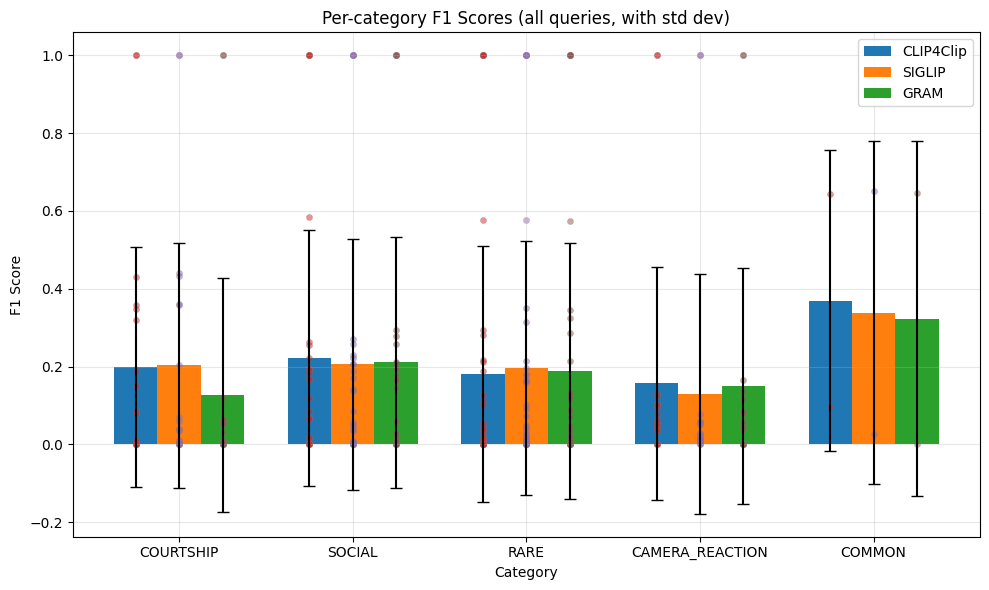

In [84]:
categories = list(merged["category"].fillna("UNKNOWN").unique())
f1_clip_means, f1_siglip_means, f1_gram_means = [], [], []
f1_clip_stds,  f1_siglip_stds,  f1_gram_stds  = [], [], []

for cat in categories:
    subset = merged[merged["category"] == cat]
    f1_clip_means.append(subset["f1_clip"].mean())
    f1_siglip_means.append(subset["f1_siglip"].mean())
    f1_gram_means.append(subset["f1_gram"].mean())
    f1_clip_stds.append(subset["f1_clip"].std())
    f1_siglip_stds.append(subset["f1_siglip"].std())
    f1_gram_stds.append(subset["f1_gram"].std())

x_pos = np.arange(len(categories))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x_pos - width, f1_clip_means, width, label="CLIP4Clip", yerr=f1_clip_stds, capsize=4)
plt.bar(x_pos,         f1_siglip_means, width, label="SIGLIP",   yerr=f1_siglip_stds, capsize=4)
plt.bar(x_pos + width, f1_gram_means, width, label="GRAM",       yerr=f1_gram_stds, capsize=4)

plt.scatter(
    [x_pos[categories.index(cat)] - width for cat in merged["category"].fillna("UNKNOWN")],
    merged["f1_clip"], alpha=0.5, edgecolors="grey", linewidths=0.3, s=20,
)
plt.scatter(
    [x_pos[categories.index(cat)] for cat in merged["category"].fillna("UNKNOWN")],
    merged["f1_siglip"], alpha=0.5, edgecolors="grey", linewidths=0.3, s=20,
)
plt.scatter(
    [x_pos[categories.index(cat)] + width for cat in merged["category"].fillna("UNKNOWN")],
    merged["f1_gram"], alpha=0.5, edgecolors="grey", linewidths=0.3, s=20,
)

plt.xlabel("Category")
plt.ylabel("F1 Score")
plt.title("Per-category F1 Scores (all queries, with std dev)")
plt.xticks(x_pos, categories)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

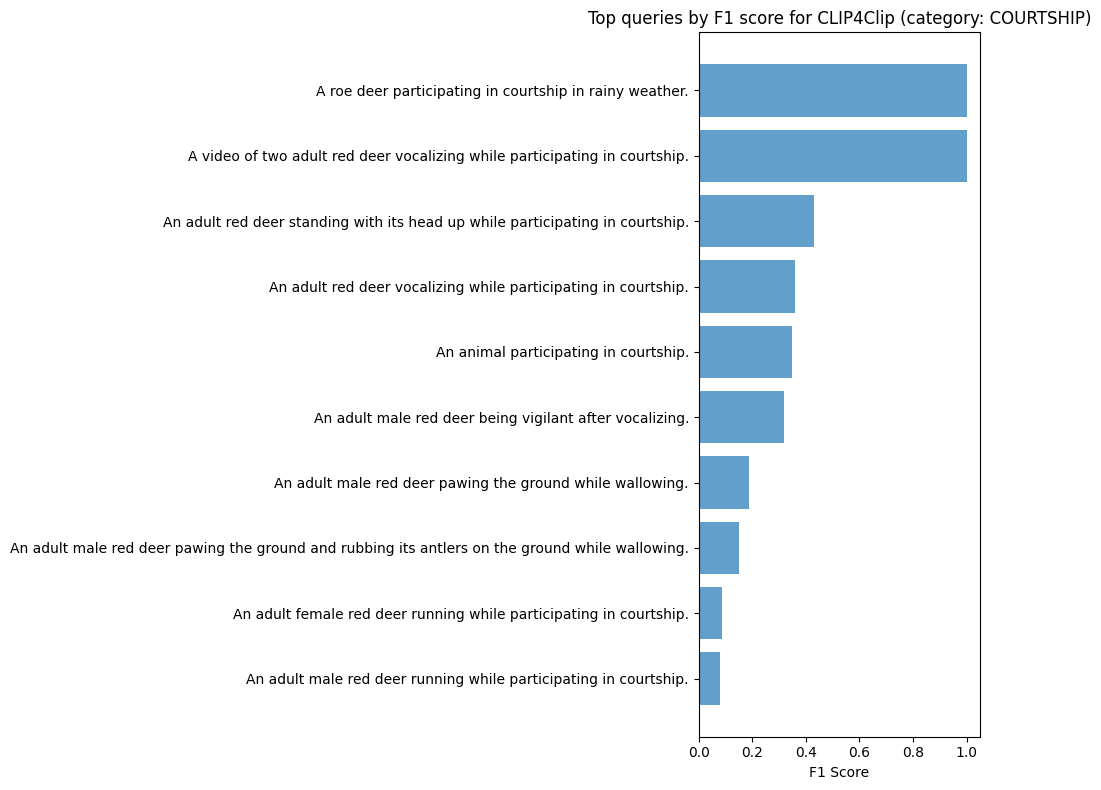

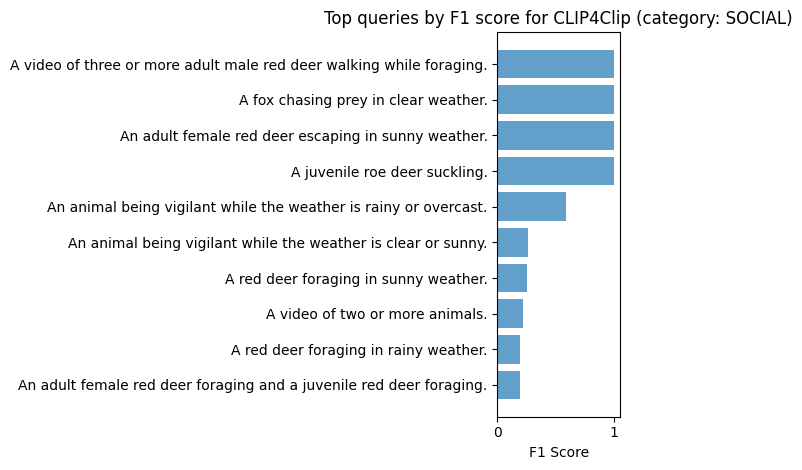

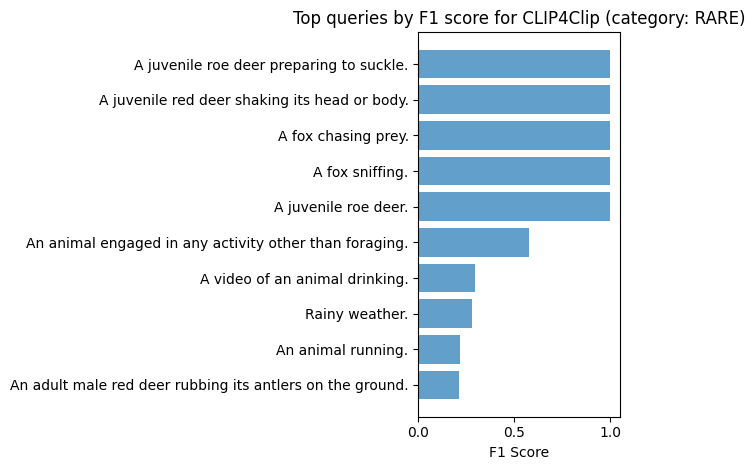

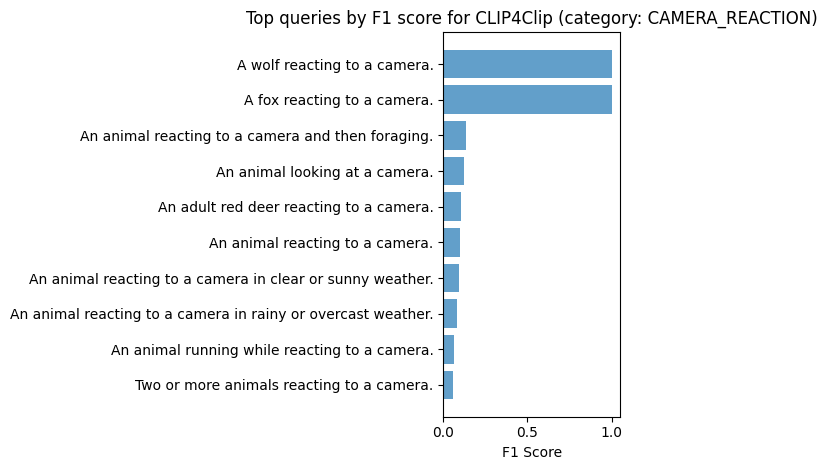

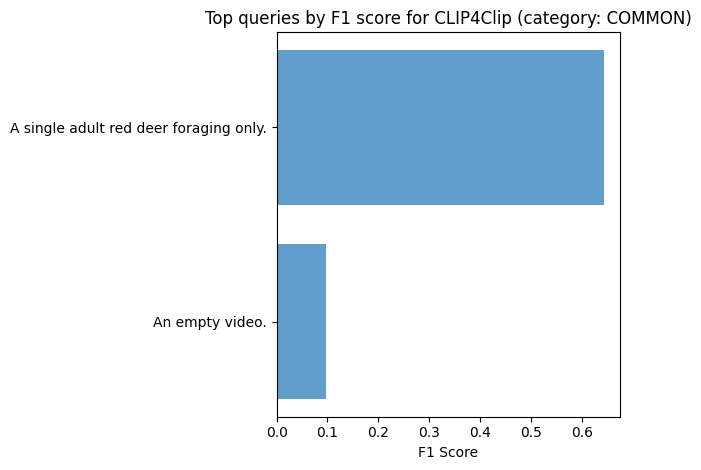

In [86]:
# plot horizantal barplot top query per category with highest F1 5 plots, that shows the top 10 queries with the highest f1 score
categories = merged["category"].unique()
plt.figure(figsize=(10, 8))
for i, cat in enumerate(categories):
    subset = merged[merged["category"] == cat]
    subset_top10 = subset.sort_values("f1_clip", ascending=False).head(10)
    # highest f1 at the top, so sort by f1_clip ascending and use barh
    subset_top10 = subset_top10.sort_values("f1_clip", ascending=True)
    plt.barh(subset_top10.index, subset_top10["f1_clip"], label=f"{cat} (CLIP4Clip)", alpha=0.7)
    plt.xlabel("F1 Score")
    plt.title(f"Top queries by F1 score for CLIP4Clip (category: {cat})")
    plt.tight_layout()
    plt.show()

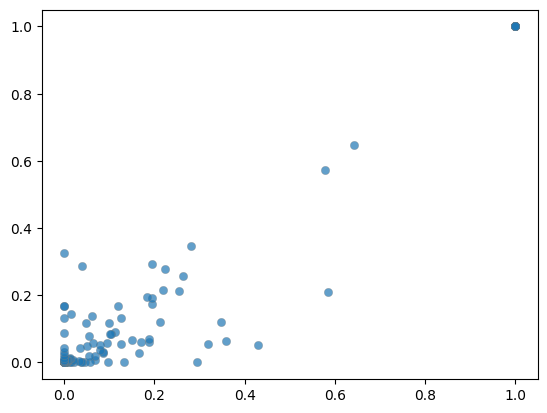

In [87]:
plt.scatter(merged["f1_clip"], merged["f1_gram"], alpha=0.7, edgecolors="grey", linewidths=0.3)